In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('03_Data_cleaned_after_pandas.csv')
df.head(2)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Binary
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,1,0,8,0,1,6,4,0,5,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,1,10,3,3,10,7,1,7,0


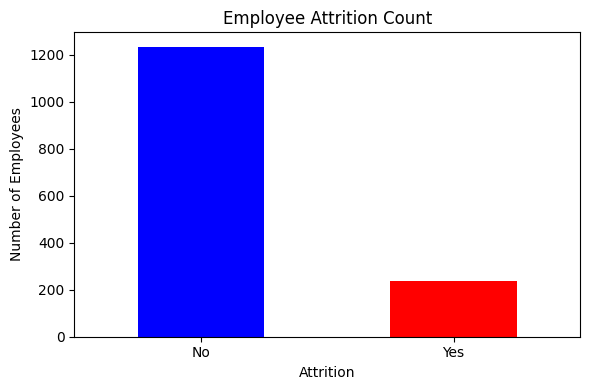

In [3]:
plt.figure(figsize=(6,4))
df['Attrition'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Employee Attrition Count')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plot1_attrition_count.png')
plt.show()

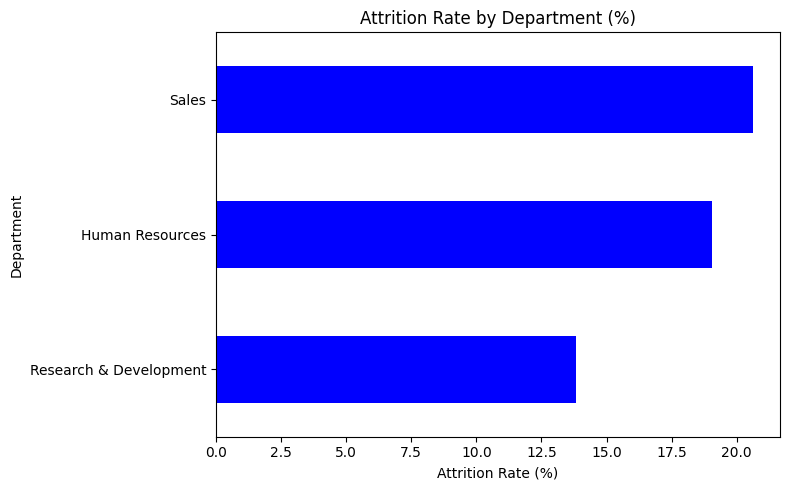

In [5]:
plt.figure(figsize=(8,5))
dept_attr = df.groupby('Department')['Attrition_Binary'].mean() * 100
dept_attr.sort_values().plot(kind='barh', color='blue')
plt.title('Attrition Rate by Department (%)')
plt.xlabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig('plot2_dept_attrition.png')
plt.show()

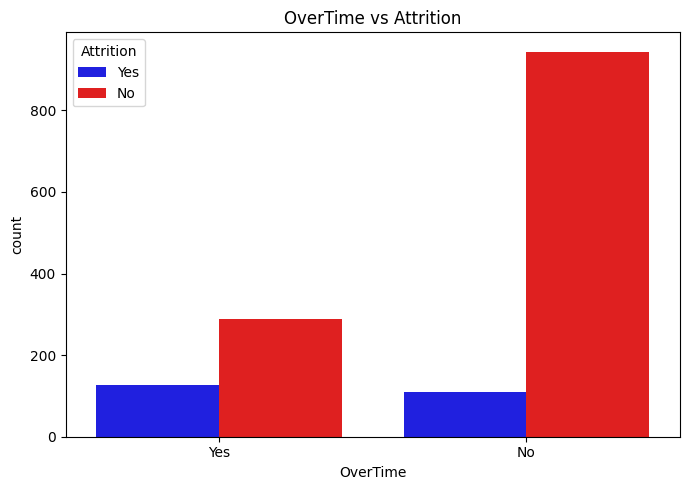

In [6]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='OverTime', hue='Attrition', palette=['blue','red'])
plt.title('OverTime vs Attrition')
plt.tight_layout()
plt.savefig('plot3_overtime_attrition.png')
plt.show()

C:\Users\YASH\AppData\Local\Temp\ipykernel_21156\2547747849.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette=['blue','red'])


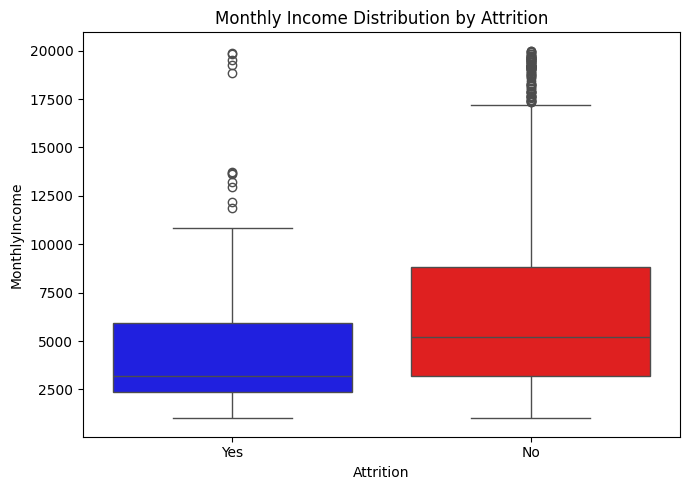

In [7]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette=['blue','red'])
plt.title('Monthly Income Distribution by Attrition')
plt.tight_layout()
plt.savefig('plot4_income_attrition.png')
plt.show()

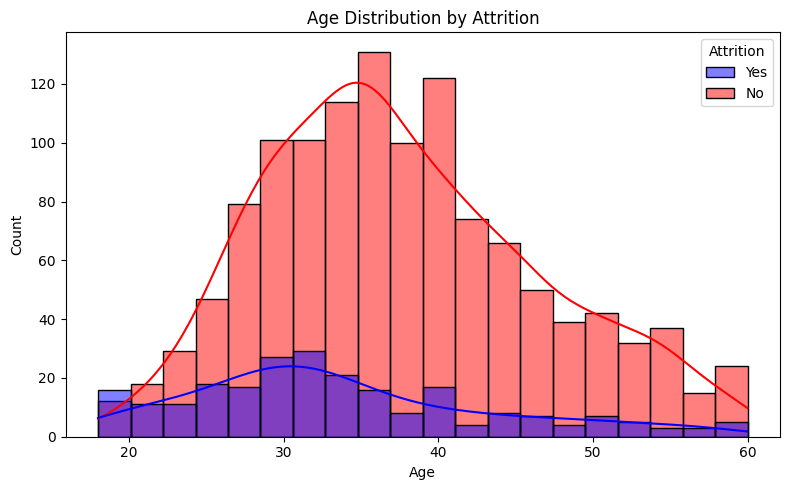

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Attrition', bins=20, palette=['blue','red'], kde=True)
plt.title('Age Distribution by Attrition')
plt.tight_layout()
plt.savefig('plot5_age_attrition.png')
plt.show()

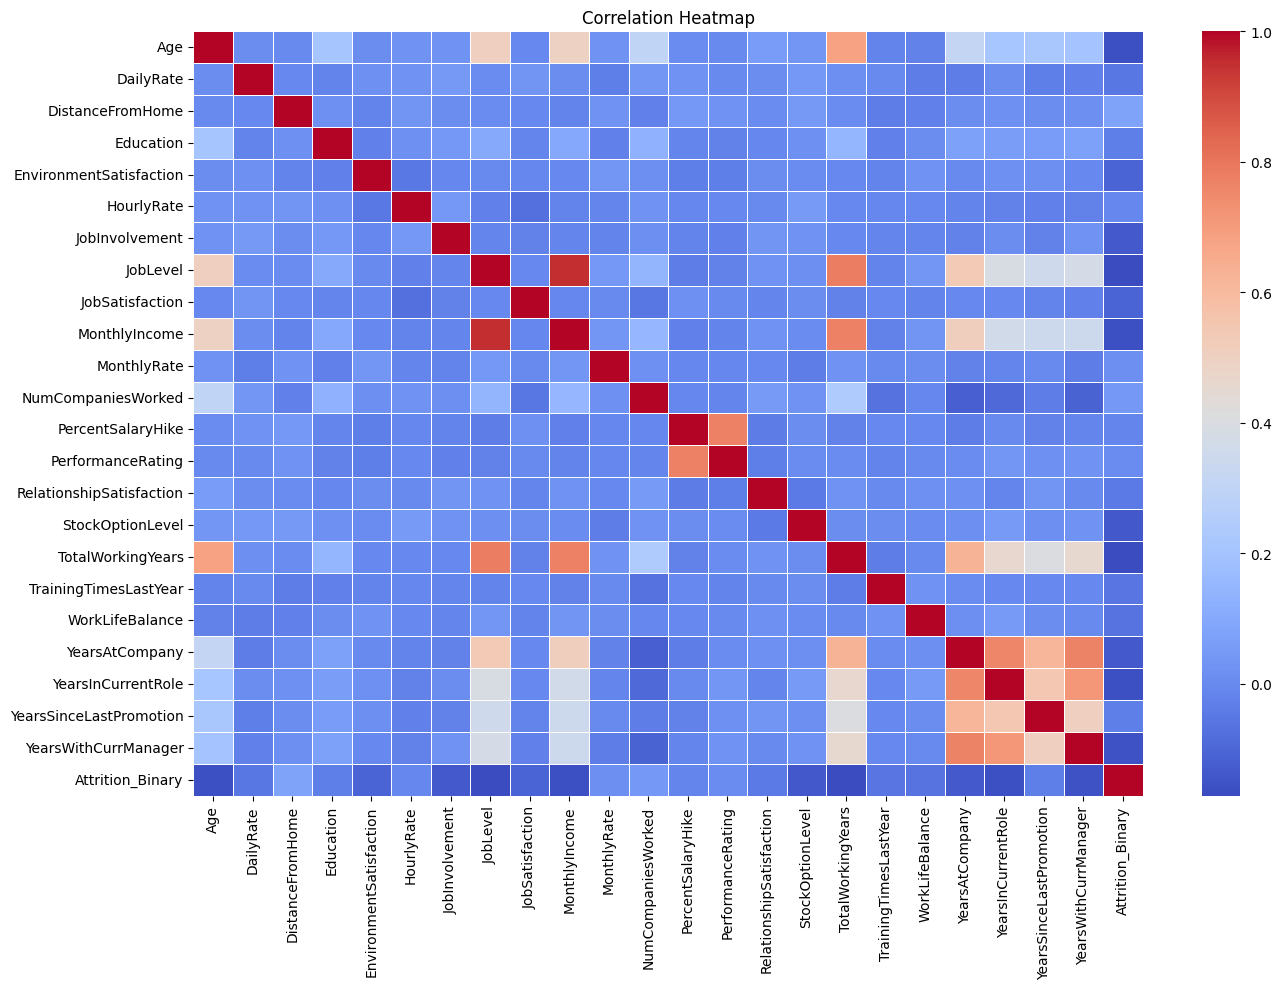

In [9]:
plt.figure(figsize=(14,10))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('plot6_correlation_heatmap.png')
plt.show()

C:\Users\YASH\AppData\Local\Temp\ipykernel_21156\1140926475.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Attrition'] = df['Attrition'].replace({'Yes': 1, 'No': 0}).astype(float)


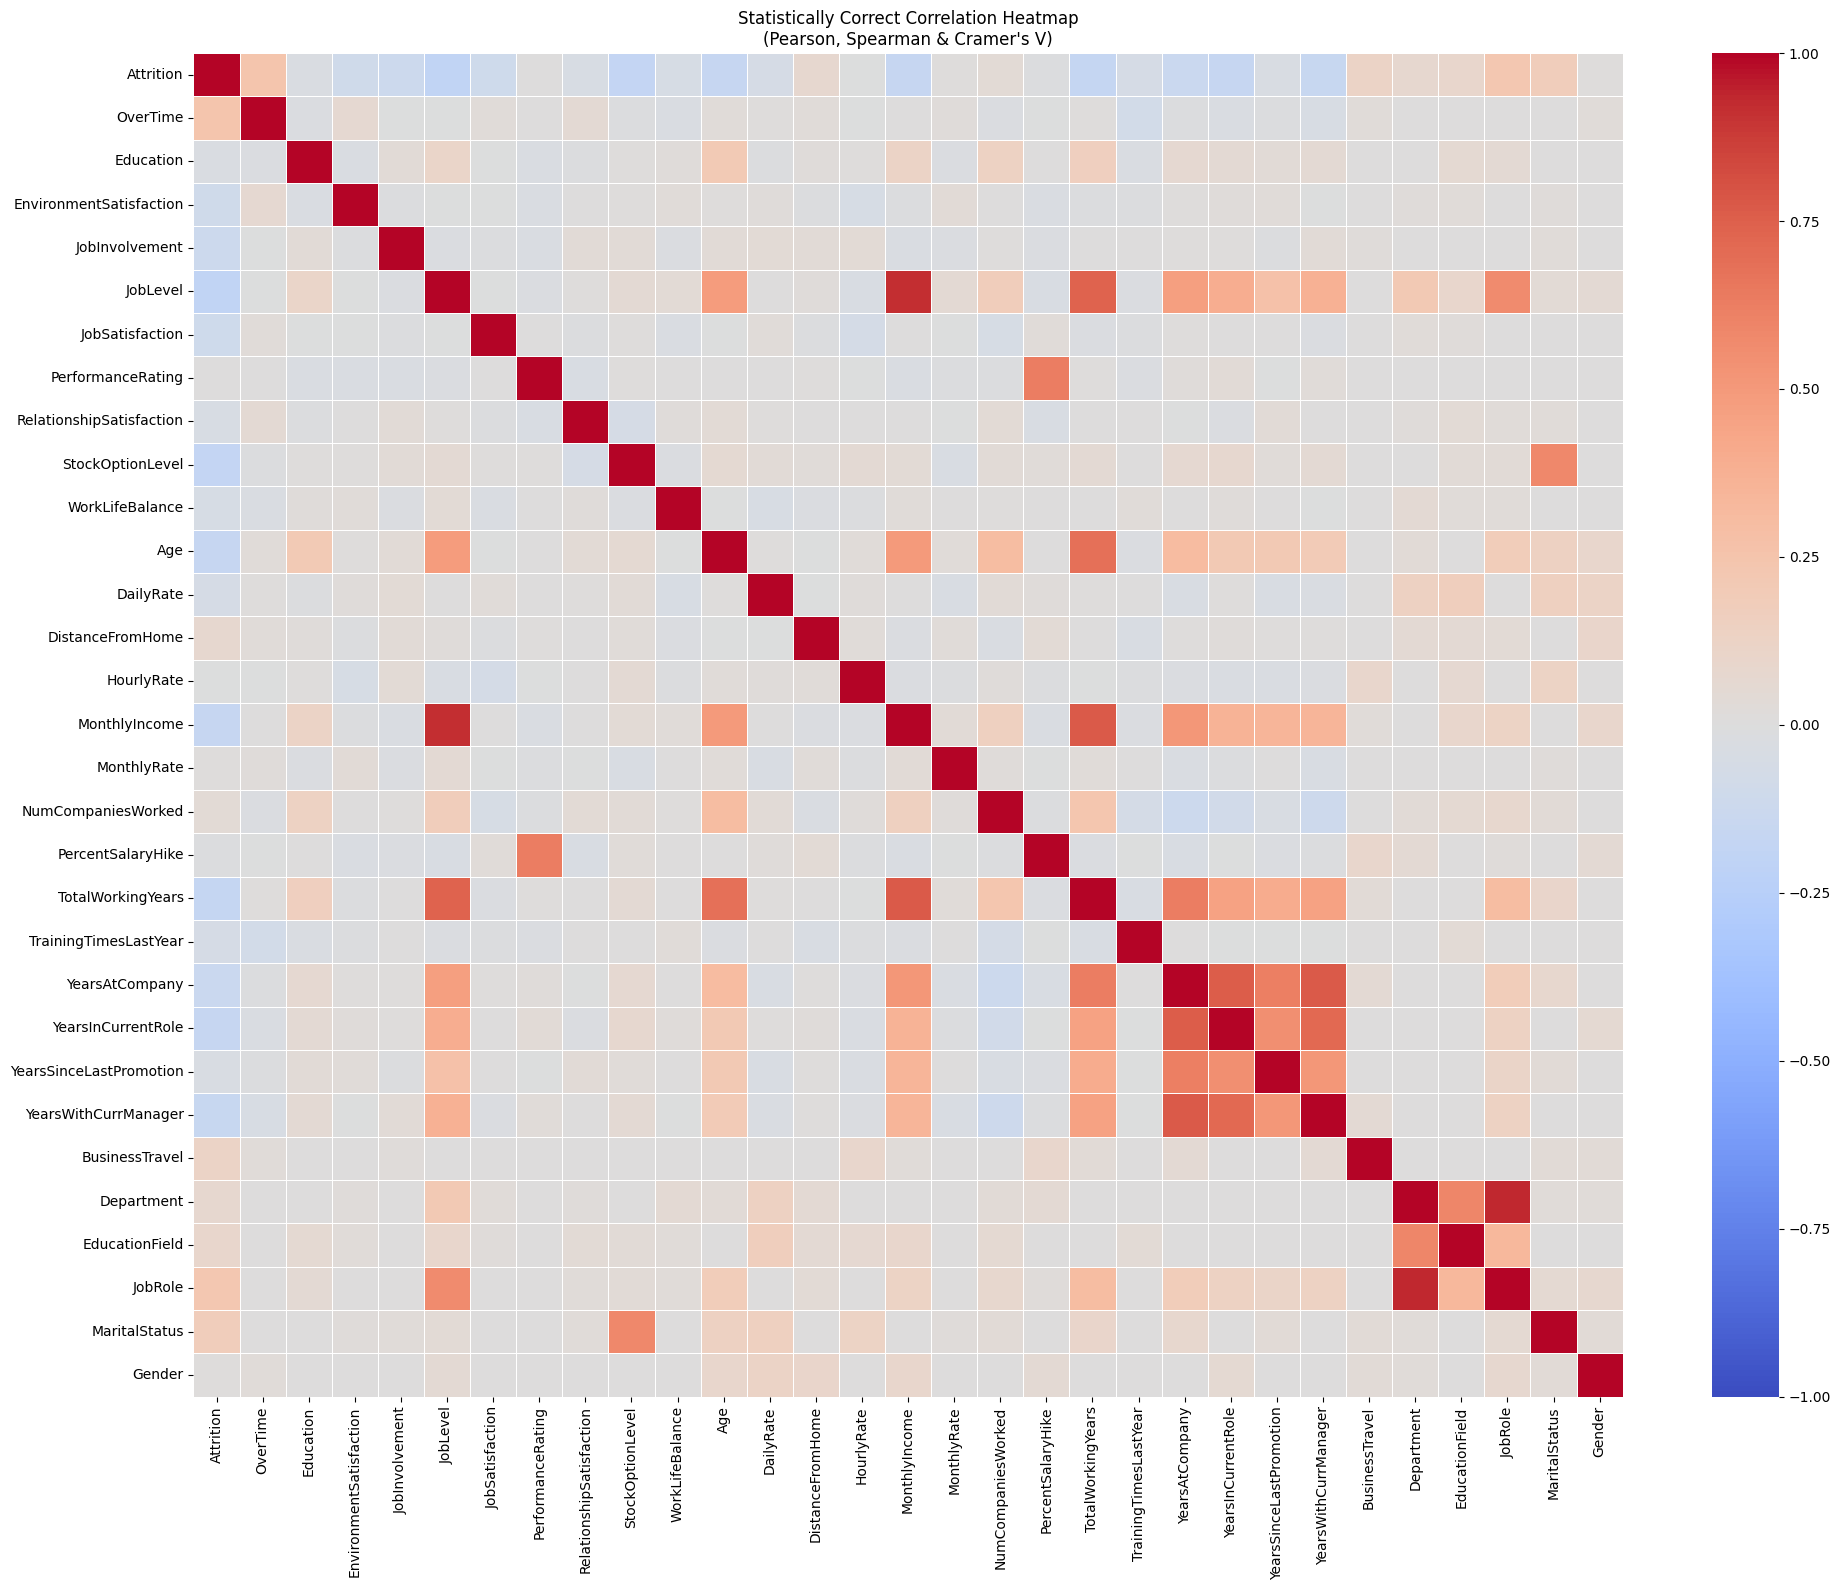

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as ss

# 2. Categorize the columns manually
binary_cols = ['Attrition', 'OverTime']
ordinal_cols = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
                'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction',
                'StockOptionLevel', 'WorkLifeBalance']
continuous_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
                   'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
                   'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany',
                   'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
nominal_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus', 'Gender']

# FIX: Use .replace() and explicitly cast to float so Jupyter doesn't overwrite with NaNs
df['Attrition'] = df['Attrition'].replace({'Yes': 1, 'No': 0}).astype(float)
df['OverTime'] = df['OverTime'].replace({'Yes': 1, 'No': 0}).astype(float)

all_features = binary_cols + ordinal_cols + continuous_cols + nominal_cols

# 3. Define Cramer's V calculation
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    if n == 0 or min(r-1, k-1) == 0: return 0.0
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    if min((kcorr-1), (rcorr-1)) == 0: return 0.0
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 4. Initialize empty DataFrame
corr_matrix = pd.DataFrame(index=all_features, columns=all_features, dtype=float)

# 5. Loop through pairs (with explicit float casting for scipy)
for col1 in all_features:
    for col2 in all_features:
        if col1 == col2:
            corr_matrix.loc[col1, col2] = 1.0
            continue
            
        if col1 in nominal_cols and col2 in nominal_cols:
            corr_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])
            
        elif (col1 in binary_cols and col2 in continuous_cols) or \
             (col2 in binary_cols and col1 in continuous_cols):
            # FIX: Force float data types here
            corr_matrix.loc[col1, col2] = ss.pearsonr(df[col1].astype(float), df[col2].astype(float))[0]
            
        elif col1 in continuous_cols and col2 in continuous_cols:
            # FIX: Force float data types here
            corr_matrix.loc[col1, col2] = ss.pearsonr(df[col1].astype(float), df[col2].astype(float))[0]
            
        elif (col1 in ordinal_cols and col2 not in nominal_cols) or \
             (col2 in ordinal_cols and col1 not in nominal_cols):
            # FIX: Force float data types here
            corr_matrix.loc[col1, col2] = ss.spearmanr(df[col1].astype(float), df[col2].astype(float))[0]
            
        else:
            corr_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

# 6. Plot the "Smart" Heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Statistically Correct Correlation Heatmap\n(Pearson, Spearman & Cramer\'s V)')
plt.tight_layout()
plt.savefig('plot6_smart_correlation_heatmap.png')
plt.show()

In [31]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Binary
0,41,1.0,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,1,0,8,0,1,6,4,0,5,1
1,49,0.0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,1,10,3,3,10,7,1,7,0
2,37,1.0,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,2,0,7,3,3,0,0,0,0,1
3,33,0.0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,0,8,3,3,8,7,3,0,0
4,27,0.0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,4,1,6,3,3,2,2,2,2,0


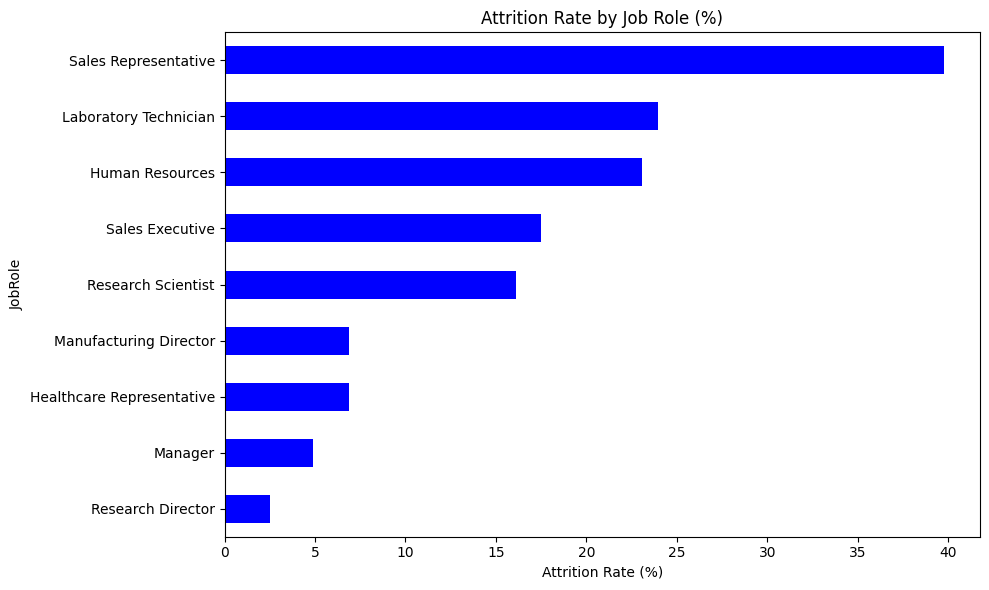

In [10]:
plt.figure(figsize=(10,6))
role_attr = df.groupby('JobRole')['Attrition_Binary'].mean() * 100
role_attr.sort_values().plot(kind='barh', color='blue')
plt.title('Attrition Rate by Job Role (%)')
plt.xlabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig('plot7_jobrole_attrition.png')
plt.show()

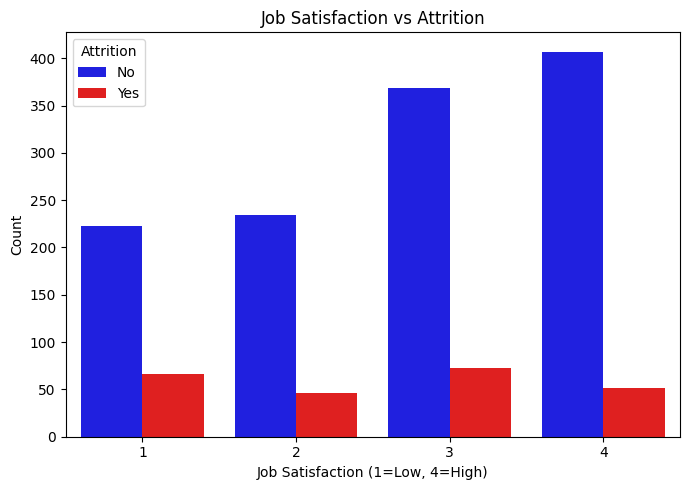

In [11]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='JobSatisfaction', hue='Attrition', palette=['blue','red'])
plt.title('Job Satisfaction vs Attrition')
plt.xlabel('Job Satisfaction (1=Low, 4=High)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plot8_jobsatisfaction_attrition.png')
plt.show()

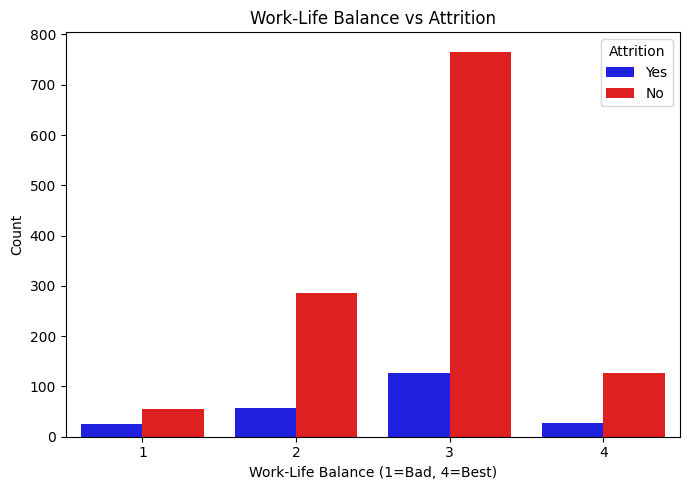

In [12]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='WorkLifeBalance', hue='Attrition', palette=['blue','red'])
plt.title('Work-Life Balance vs Attrition')
plt.xlabel('Work-Life Balance (1=Bad, 4=Best)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plot9_worklifebalance_attrition.png')
plt.show()

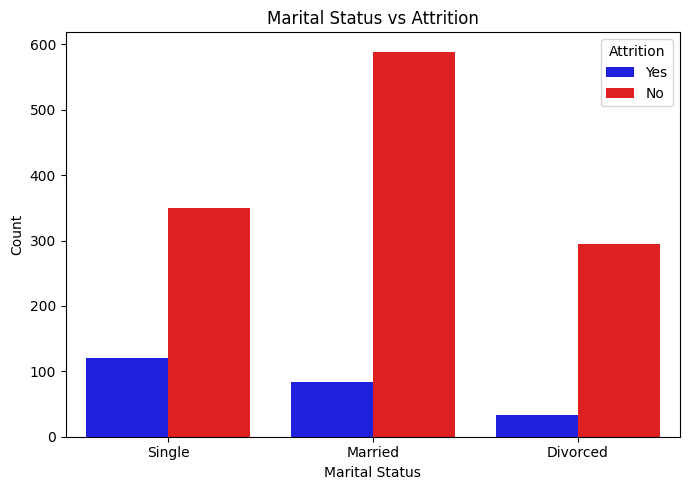

In [14]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='MaritalStatus', hue='Attrition', palette=['blue','red'])
plt.title('Marital Status vs Attrition')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plot10_maritalstatus_attrition.png')
plt.show()

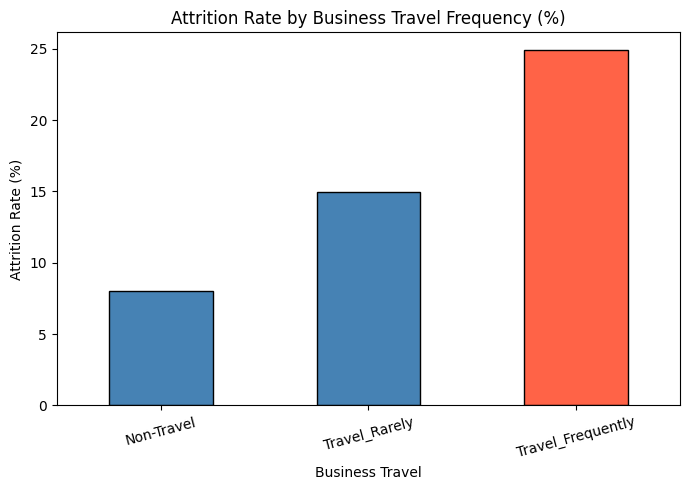

In [15]:
plt.figure(figsize=(7,5))
travel_attr = df.groupby('BusinessTravel')['Attrition_Binary'].mean() * 100
travel_attr.sort_values().plot(kind='bar', color=['steelblue','steelblue','tomato'], edgecolor='black')
plt.title('Attrition Rate by Business Travel Frequency (%)')
plt.xlabel('Business Travel')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('plot11_businesstravel_attrition.png')
plt.show()

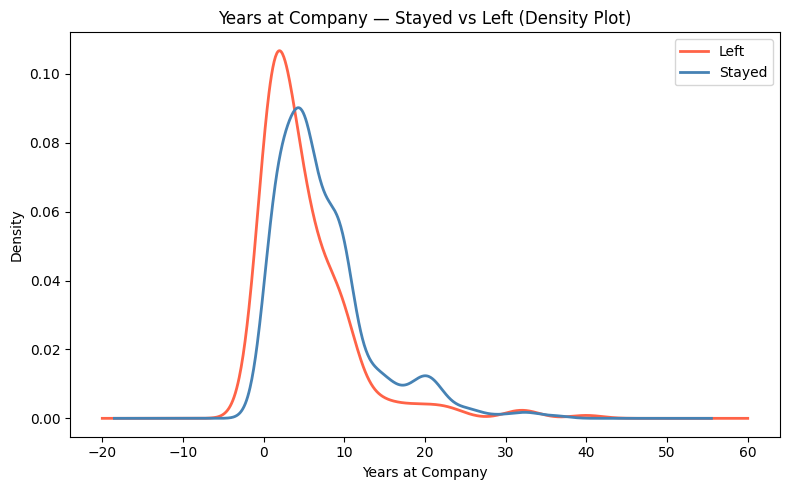

In [16]:
plt.figure(figsize=(8,5))
df[df['Attrition']=='Yes']['YearsAtCompany'].plot(kind='density', label='Left', color='tomato', linewidth=2)
df[df['Attrition']=='No']['YearsAtCompany'].plot(kind='density', label='Stayed', color='steelblue', linewidth=2)
plt.title('Years at Company — Stayed vs Left (Density Plot)')
plt.xlabel('Years at Company')
plt.legend()
plt.tight_layout()
plt.savefig('plot12_yearsatcompany_attrition.png')
plt.show()

C:\Users\YASH\AppData\Local\Temp\ipykernel_21156\263523132.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='DistanceFromHome', palette=['steelblue','tomato'])


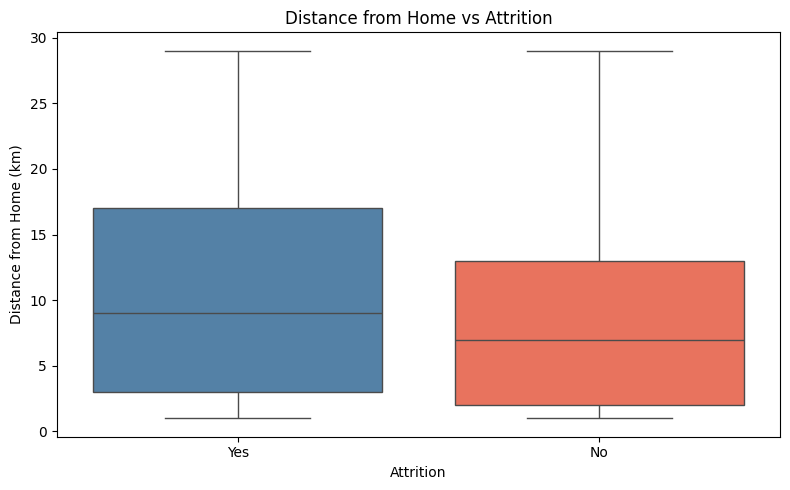

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Attrition', y='DistanceFromHome', palette=['steelblue','tomato'])
plt.title('Distance from Home vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Distance from Home (km)')
plt.tight_layout()
plt.savefig('plot13_distancefromhome_attrition.png')
plt.show()

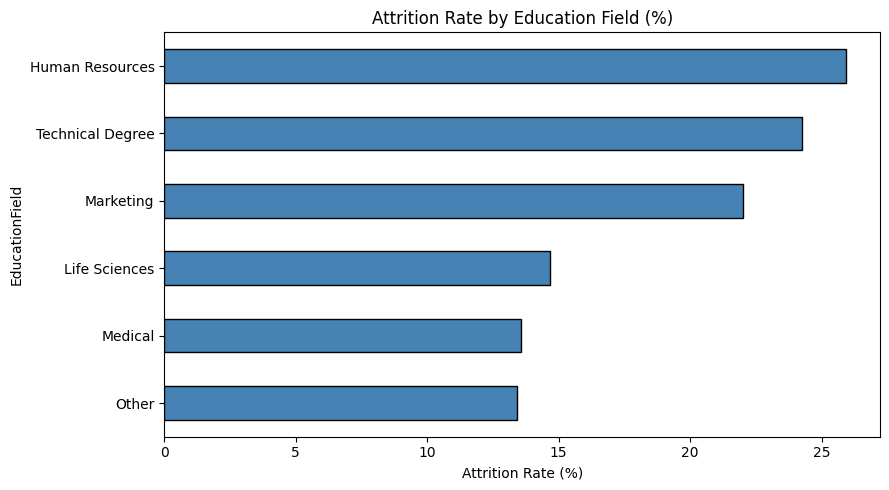

In [18]:
plt.figure(figsize=(9,5))
edu_attr = df.groupby('EducationField')['Attrition_Binary'].mean() * 100
edu_attr.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Attrition Rate by Education Field (%)')
plt.xlabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig('plot14_educationfield_attrition.png')
plt.show()

C:\Users\YASH\AppData\Local\Temp\ipykernel_21156\3912535116.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='NumCompaniesWorked', palette=['steelblue','tomato'])


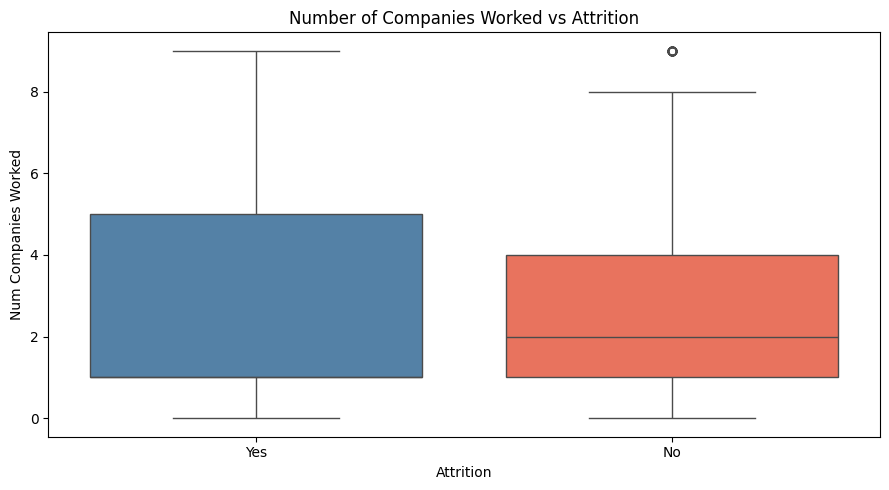

In [19]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='Attrition', y='NumCompaniesWorked', palette=['steelblue','tomato'])
plt.title('Number of Companies Worked vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Num Companies Worked')
plt.tight_layout()
plt.savefig('plot15_numcompanies_attrition.png')
plt.show()

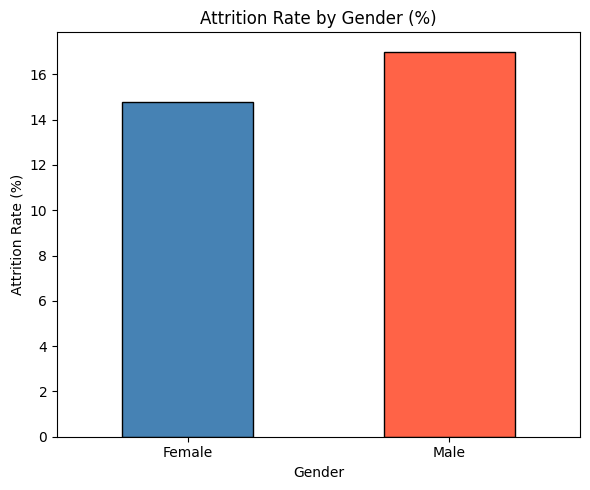

In [20]:
plt.figure(figsize=(6,5))
gender_attr = df.groupby('Gender')['Attrition_Binary'].mean() * 100
gender_attr.plot(kind='bar', color=['steelblue','tomato'], edgecolor='black')
plt.title('Attrition Rate by Gender (%)')
plt.xlabel('Gender')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plot16_gender_attrition.png')
plt.show()

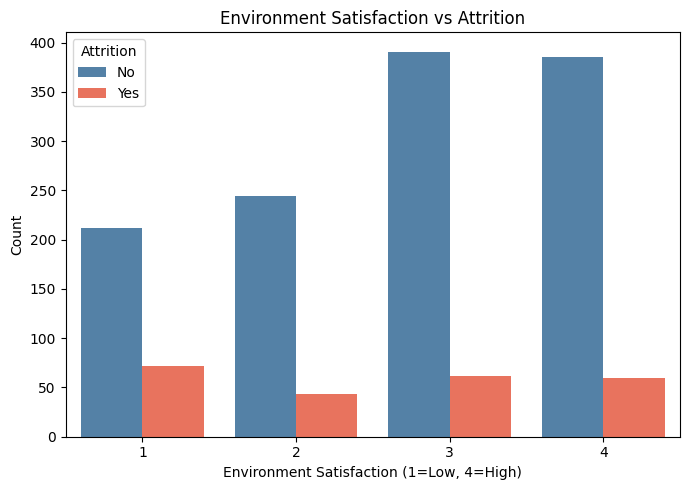

In [21]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='EnvironmentSatisfaction', hue='Attrition', palette=['steelblue','tomato'])
plt.title('Environment Satisfaction vs Attrition')
plt.xlabel('Environment Satisfaction (1=Low, 4=High)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plot17_environmentsatisfaction_attrition.png')
plt.show()

C:\Users\YASH\AppData\Local\Temp\ipykernel_21156\2173644897.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='YearsSinceLastPromotion', palette=['steelblue','tomato'])


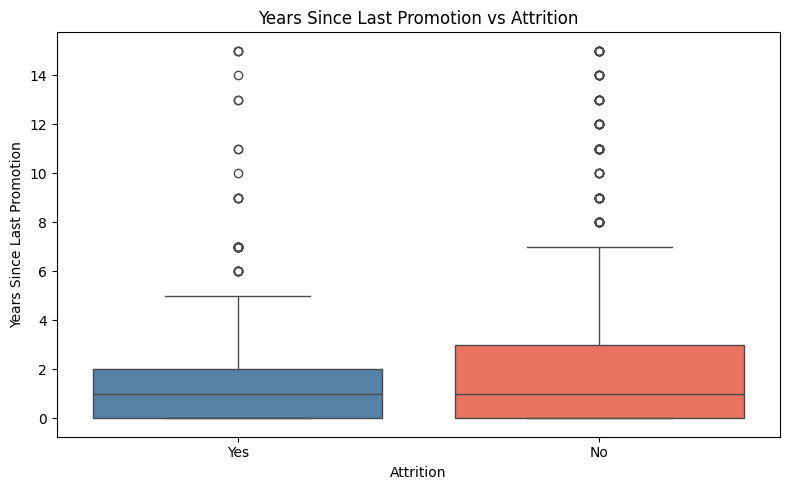

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Attrition', y='YearsSinceLastPromotion', palette=['steelblue','tomato'])
plt.title('Years Since Last Promotion vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Years Since Last Promotion')
plt.tight_layout()
plt.savefig('plot18_promotion_attrition.png')
plt.show()

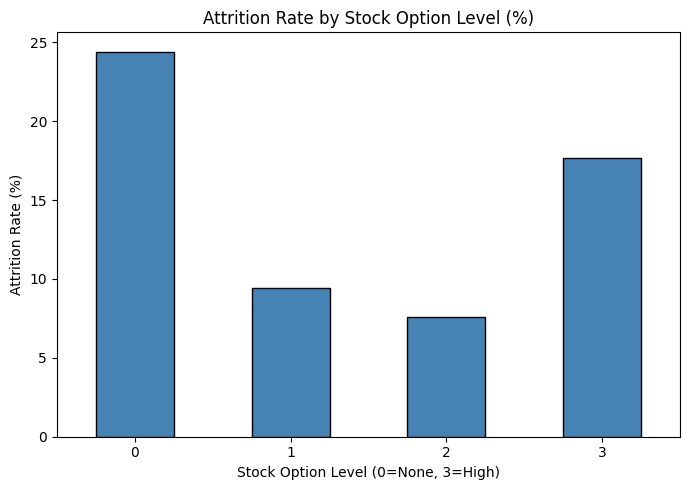

In [23]:
plt.figure(figsize=(7,5))
stock_attr = df.groupby('StockOptionLevel')['Attrition_Binary'].mean() * 100
stock_attr.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Attrition Rate by Stock Option Level (%)')
plt.xlabel('Stock Option Level (0=None, 3=High)')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plot19_stockoption_attrition.png')
plt.show()

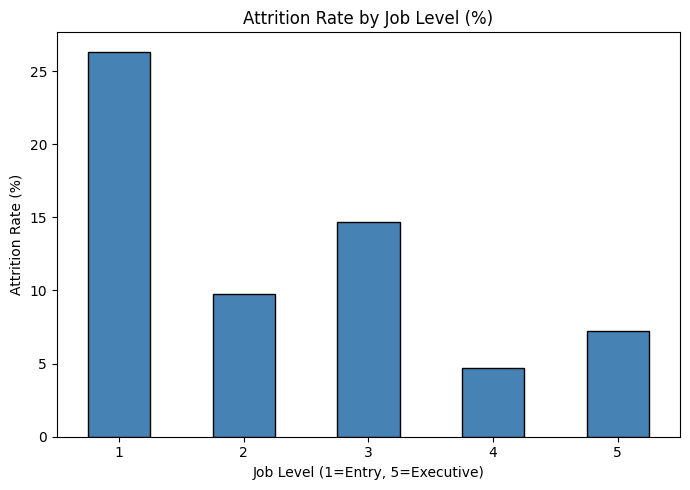

In [24]:
plt.figure(figsize=(7,5))
joblevel_attr = df.groupby('JobLevel')['Attrition_Binary'].mean() * 100
joblevel_attr.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Attrition Rate by Job Level (%)')
plt.xlabel('Job Level (1=Entry, 5=Executive)')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plot20_joblevel_attrition.png')
plt.show()

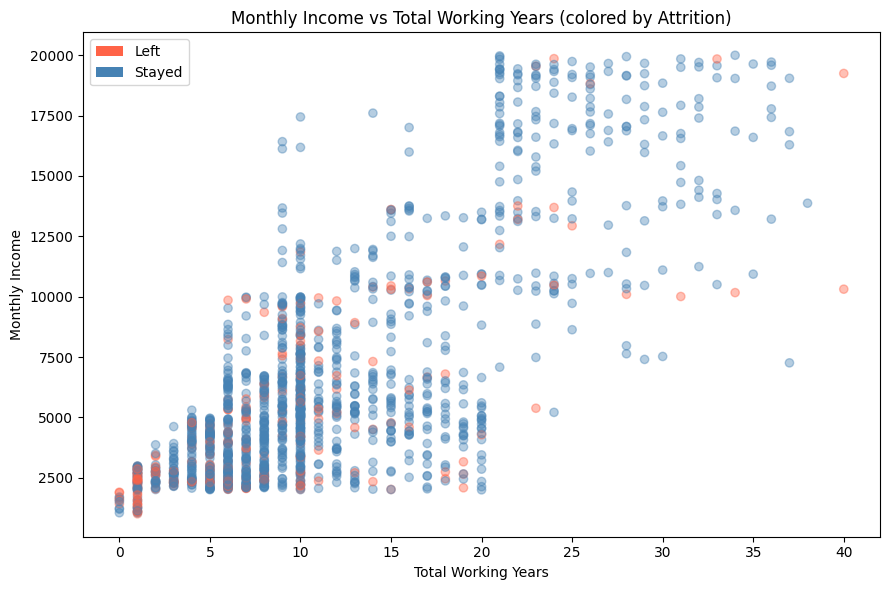

In [25]:
plt.figure(figsize=(9,6))
colors = df['Attrition'].map({'Yes': 'tomato', 'No': 'steelblue'})
plt.scatter(df['TotalWorkingYears'], df['MonthlyIncome'], c=colors, alpha=0.4)
plt.title('Monthly Income vs Total Working Years (colored by Attrition)')
plt.xlabel('Total Working Years')
plt.ylabel('Monthly Income')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='tomato', label='Left'), Patch(facecolor='steelblue', label='Stayed')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('plot21_income_vs_experience_scatter.png')
plt.show()

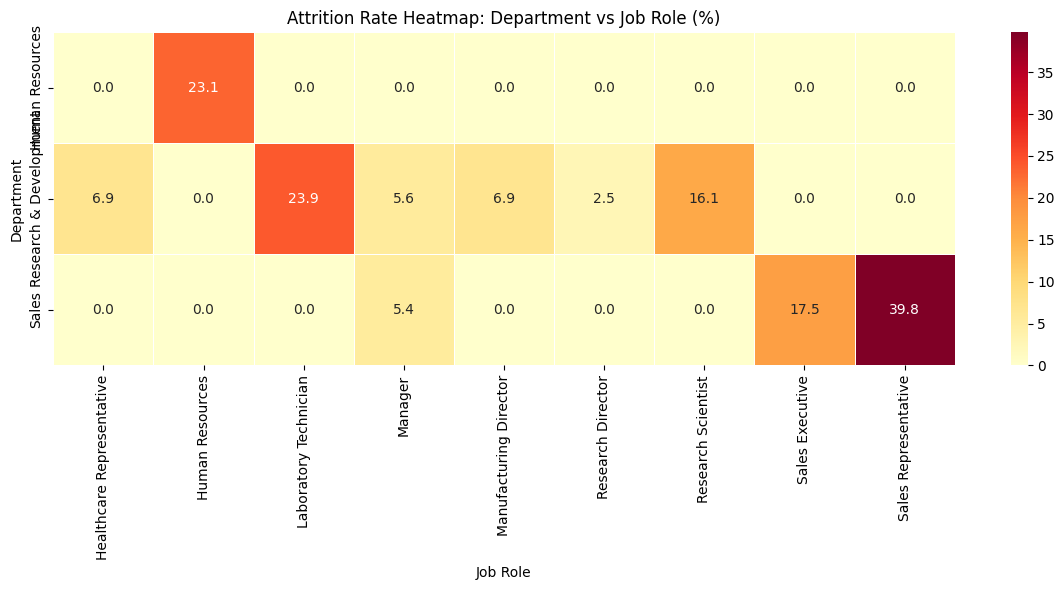

In [26]:
plt.figure(figsize=(12,6))
pivot = df.groupby(['Department','JobRole'])['Attrition_Binary'].mean() * 100
pivot = pivot.unstack().fillna(0)
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Attrition Rate Heatmap: Department vs Job Role (%)')
plt.ylabel('Department')
plt.xlabel('Job Role')
plt.tight_layout()
plt.savefig('plot22_dept_jobrole_heatmap.png')
plt.show()